# 0. Environment Dependencies

In [57]:
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")

DATA_DIR = "data/raw/"

# 1. Load datasets

In [58]:
print("Loading datasets...")

df_orders      = pd.read_csv(DATA_DIR + "orders.csv", parse_dates=["order_date"])
df_order_items = pd.read_csv(DATA_DIR + "order_items.csv", low_memory=False)
df_products    = pd.read_csv(DATA_DIR + "products.csv")
df_promotions  = pd.read_csv(DATA_DIR + "promotions.csv", parse_dates=["start_date", "end_date"])
df_customers   = pd.read_csv(DATA_DIR + "customers.csv", parse_dates=["signup_date"])
df_geography   = pd.read_csv(DATA_DIR + "geography.csv")
df_payments    = pd.read_csv(DATA_DIR + "payments.csv")
df_returns     = pd.read_csv(DATA_DIR + "returns.csv", parse_dates=["return_date"])
df_reviews     = pd.read_csv(DATA_DIR + "reviews.csv", parse_dates=["review_date"])
df_shipments   = pd.read_csv(DATA_DIR + "shipments.csv", parse_dates=["ship_date", "delivery_date"])
df_inventory   = pd.read_csv(DATA_DIR + "inventory.csv", parse_dates=["snapshot_date"])
df_web_traffic = pd.read_csv(DATA_DIR + "web_traffic.csv", parse_dates=["date"])
df_sales       = pd.read_csv(DATA_DIR + "sales.csv", parse_dates=["Date"])

print("All datasets loaded.\n")

Loading datasets...
All datasets loaded.



# 2. EDA

## VẤN ĐỀ TRONG DỮ LIỆU TỒN KHO

- **Tổng lượng hàng tồn kho qua các năm**

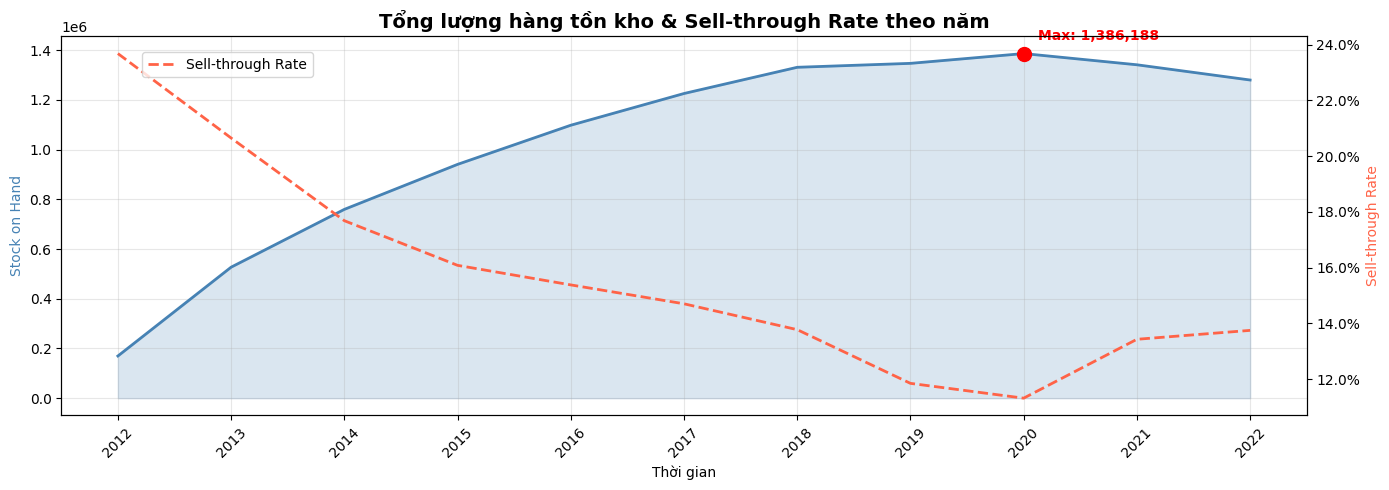

In [59]:
stock_by_date = df_inventory.groupby(['year']).agg(
    stock_on_hand     = ('stock_on_hand', 'sum'),
    sell_through_rate = ('sell_through_rate', 'mean')
).reset_index()
stock_by_date['period'] = stock_by_date['year'].astype(str)

max_idx = stock_by_date['stock_on_hand'].idxmax()
max_period = stock_by_date.loc[max_idx, 'period']
max_value = stock_by_date.loc[max_idx, 'stock_on_hand']

fig, ax1 = plt.subplots(figsize=(14, 5))

# Trục trái: stock_on_hand
ax1.plot(stock_by_date['period'], stock_by_date['stock_on_hand'], color='steelblue', linewidth=2)
ax1.fill_between(stock_by_date['period'], stock_by_date['stock_on_hand'], alpha=0.2, color='steelblue')
ax1.scatter(max_period, max_value, color='red', zorder=5, s=100)
ax1.annotate(f'Max: {max_value:,.0f}', xy=(max_period, max_value),
             xytext=(10, 10), textcoords='offset points',
             fontsize=10, color='red', fontweight='bold')
ax1.set_xlabel('Thời gian')
ax1.set_ylabel('Stock on Hand', color='steelblue')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3)

# Trục phải: sell_through_rate
ax2 = ax1.twinx()
ax2.plot(stock_by_date['period'], stock_by_date['sell_through_rate'], 
         color='tomato', linewidth=2, linestyle='--', label='Sell-through Rate')
ax2.set_ylabel('Sell-through Rate', color='tomato')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1%}'))

plt.title('Tổng lượng hàng tồn kho & Sell-through Rate theo năm', fontsize=14, fontweight='bold')
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
plt.tight_layout()
plt.show()

In [60]:
# Tính trung bình sell-through rate qua từng năm
print(f"Trung bình sell-through rate theo từng năm: {df_inventory.groupby('year')['sell_through_rate'].mean().reset_index().to_string(index=False)}")
print(f"Trung bình sell-through cho toàn bộ dữ liệu: {df_inventory['sell_through_rate'].mean():.2%}")

Trung bình sell-through rate theo từng năm:  year  sell_through_rate
 2012           0.236818
 2013           0.206518
 2014           0.176848
 2015           0.160828
 2016           0.153811
 2017           0.147030
 2018           0.137749
 2019           0.118483
 2020           0.113169
 2021           0.134295
 2022           0.137494
Trung bình sell-through cho toàn bộ dữ liệu: 15.23%


Tổng lượng hàng tồn kho tăng đều qua các năm, đạt đỉnh với số lượng hàng tồn là 1386188 vào năm 2020. Tỷ lệ sell-through rate trung bình lao dốc từ nằm 2012 -> 2020. Ở các giai đoạn sau có tăng lên nhưng vẫn thấp hơn so với năm khởi điểm của dữ liệu, chỉ đạt ~13.75%.

- **Sự bất đồng bộ giữa df_inventory và df_order_items**

In [61]:
df_order_with_dates = df_order_items.merge(df_orders, on='order_id', how='left')
df_order_items_final = df_order_with_dates.merge(df_shipments, on='order_id', how='left')
df_order_items_final['order_month'] = pd.to_datetime(df_order_items_final['order_date']).dt.to_period('M')
df_order_items_final['ship_month'] = pd.to_datetime(df_order_items_final['ship_date']).dt.to_period('M')
df_order_items_final['delivery_month'] = pd.to_datetime(df_order_items_final['delivery_date']).dt.to_period('M')

# df_order_items_final = df_order_items_with_dates_2.merge(df_returns, on=['order_id', 'product_id'], how='left')

In [62]:
# 1. Tính delivered: group theo delivery_date
delivered = df_order_items_final[df_order_items_final['order_status'] == 'delivered'].copy()
delivered_grouped = delivered.groupby(['product_id', 'ship_month'])['quantity'].sum().reset_index(name='qty_delivered')

# 2. Tính shipped: group theo ship_date
shipped = df_order_items_final[df_order_items_final['order_status'] == 'shipped'].copy()
shipped_grouped = shipped.groupby(['product_id', 'ship_month'])['quantity'].sum().reset_index(name='qty_shipped')

# Ghép delivered với bảng df_inventory
df_inventory_final = df_inventory.copy()
df_inventory_final['year_month'] = pd.to_datetime(df_inventory_final['snapshot_date']).dt.to_period('M')
df_inventory_final = df_inventory_final.merge(delivered_grouped, left_on=['year_month', 'product_id'], right_on=['ship_month', 'product_id'], how='left')
# Ghép shipped với bảng df_inventory
df_inventory_final = df_inventory_final.merge(shipped_grouped, left_on=['year_month', 'product_id'], right_on=['ship_month', 'product_id'], how='left')
df_inventory_final['qty_delivered_shipped'] = df_inventory_final['qty_delivered'].fillna(0) + df_inventory_final['qty_shipped'].fillna(0)
df_inventory_final['qty_difference'] = df_inventory_final['qty_delivered_shipped'] - df_inventory_final['units_sold']
df_inventory_final = df_inventory_final.merge(df_products[['product_id', 'color', 'size', 'cogs']], on='product_id', how='left')

In [63]:
print(f"Tỷ lệ record mà units_sold = qty_delivered_shipped: {(len(df_inventory_final[df_inventory_final['qty_difference'] == 0])/len(df_inventory_final))*100}%")
print(f"Tỷ lệ record mà units_sold < qty_delivered_shipped: {(len(df_inventory_final[df_inventory_final['qty_difference'] > 0])/len(df_inventory_final))*100}%")
print(f"Tỷ lệ record mà units_sold > qty_delivered_shipped: {(len(df_inventory_final[df_inventory_final['qty_difference'] < 0])/len(df_inventory_final))*100}%")

Tỷ lệ record mà units_sold = qty_delivered_shipped: 3.045794811359902%
Tỷ lệ record mà units_sold < qty_delivered_shipped: 83.78508473450961%
Tỷ lệ record mà units_sold > qty_delivered_shipped: 13.169120454130494%


## ĐI TÌM NGUYÊN NHÂN

### 1. Tại sao số lượng tồn kho lại tăng nhiều đến như vậy?

#### Giả thuyết số 1: Số lượng tồn kho có liên quan tới việc xử lý đơn hàng và thời gian vận chuyển không?

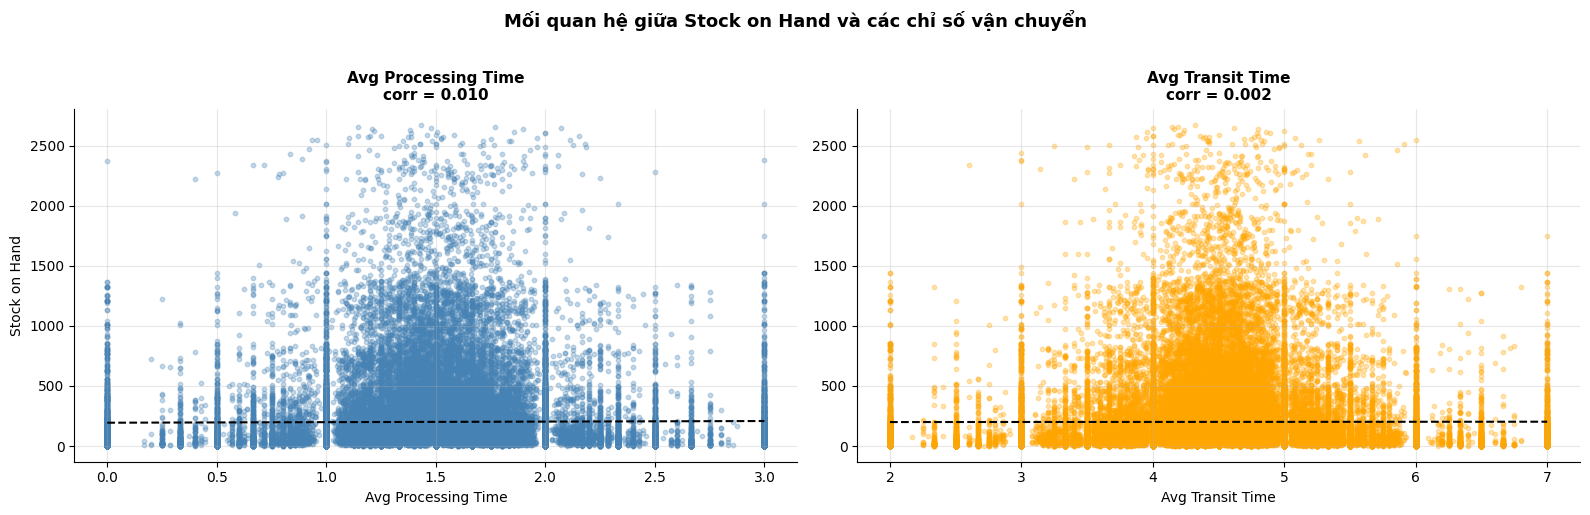

In [64]:
# Tính processing_time và transit_time
df_order_items_final['processing_time'] = (pd.to_datetime(df_order_items_final['ship_date']) - 
                                            pd.to_datetime(df_order_items_final['order_date'])).dt.days

df_order_items_final['transit_time'] = (pd.to_datetime(df_order_items_final['delivery_date']) - 
                                         pd.to_datetime(df_order_items_final['ship_date'])).dt.days

# Group theo product_id và month
df_order_items_final['ship_month'] = pd.to_datetime(df_order_items_final['ship_date']).dt.to_period('M')

shipping_monthly = df_order_items_final.groupby(['product_id', 'ship_month']).agg(
    avg_processing = ('processing_time', 'mean'),
    avg_transit    = ('transit_time', 'mean'),
).reset_index().rename(columns={'ship_month': 'year_month'})

# Merge với inventory
compare_shipping = pd.merge(
    df_inventory_final,
    shipping_monthly,
    on=['product_id', 'year_month'],
    how='inner'
)

# # Correlation
# print("--- CORRELATION với stock_on_hand ---")
# print(compare_shipping[['stock_on_hand', 'avg_processing', 'avg_transit']].corr()['stock_on_hand'].round(3))

corr_values = compare_shipping[['stock_on_hand', 'avg_processing', 'avg_transit']].corr()['stock_on_hand'].drop('stock_on_hand')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

scatter_pairs = [
    ('avg_processing', 'Avg Processing Time', 'steelblue'),
    ('avg_transit',    'Avg Transit Time',    'orange'),
]

for ax, (col, label, color) in zip(axes, scatter_pairs):
    ax.scatter(compare_shipping[col], compare_shipping['stock_on_hand'],
               alpha=0.3, s=10, color=color)
    
    # Trendline
    z = np.polyfit(compare_shipping[col].dropna(), 
                   compare_shipping.loc[compare_shipping[col].notna(), 'stock_on_hand'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(compare_shipping[col].min(), compare_shipping[col].max(), 100)
    ax.plot(x_line, p(x_line), color='black', linewidth=1.5, linestyle='--')
    
    corr = compare_shipping[col].corr(compare_shipping['stock_on_hand'])
    ax.set_title(f'{label}\ncorr = {corr:.3f}', fontsize=11, fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('Stock on Hand' if col == 'avg_processing' else '')
    ax.grid(True, alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Mối quan hệ giữa Stock on Hand và các chỉ số vận chuyển', 
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Độ tương quan giữa số lượng hàng tồn cho mỗi sản phẩm và thời gian xử lý trung bình, thời gian vận chuyển trung bình rất thấp, cho thấy tình trạng tồn hàng không liên quan tới quá trình đơn hàng tới tay người người nhận.

#### Giả thuyết số 2: Liệu những sản phẩm đang ‘nằm trên tay’ là những sản phẩm chết, được kho ghi nhận là không bao giờ được đem ra phục vụ nữa?

In [65]:
# 1. BẮT BUỘC: Sắp xếp dữ liệu chuẩn xác theo Thời gian (Cũ đến Mới) cho từng Sản phẩm
df_sorted = df_inventory_final.sort_values(by=['product_id', 'year', 'month'])

# is_monotonic_increasing sẽ trả về True nếu chuỗi số chỉ có Tăng hoặc Đứng im (không bao giờ giảm)
monotonic_check = df_sorted.groupby('product_id')['stock_on_hand'].is_monotonic_increasing

print("--- THỐNG KÊ XU HƯỚNG TỒN KHO CỦA CÁC SẢN PHẨM ---")
print(f"Tổng số sản phẩm (tính theo product_id) trong bảng df_inventory: {len(monotonic_check)}")
print(f"Số sản phẩm có tồn kho luôn tăng dần hoặc giữ nguyên theo thời gian: {monotonic_check.sum()}")
print(f"Tỷ lệ tồn kho tăng hoặc giữ nguyên theo thời gian: {(monotonic_check.sum() / len(monotonic_check)) * 100:.2f}%\n")

# Vẽ biểu đồ
# Tính độ chênh lệch tồn kho giữa tháng này và tháng trước của cùng 1 sản phẩm
df_sorted['stock_change'] = df_sorted.groupby('product_id')['stock_on_hand'].diff()

# Lọc ra những sản phẩm thuộc dạng "Bệnh nặng nhất" (Ví dụ: Tồn kho chưa bao giờ bị âm/giảm trong suốt lịch sử)
# Bước 1: Tìm những product_id ĐÃ TỪNG có sự giảm tồn kho (stock_change < 0)
products_with_stock_drops = df_sorted[df_sorted['stock_change'] < 0]['product_id'].unique()

# Bước 2: Loại trừ chúng ra để lấy những thằng CHƯA BAO GIỜ GIẢM
never_dropped_products = df_sorted[~df_sorted['product_id'].isin(products_with_stock_drops)]

# Gom nhóm để xem những thằng "Chưa bao giờ giảm" này đã tồn tại bao nhiêu tháng
zombie_growth = never_dropped_products.groupby(['product_id', 'product_name']).agg(
    months_alive=('month', 'count'),          # Sống được bao nhiêu tháng rồi?
    start_stock=('stock_on_hand', 'first'),   # Tồn kho tháng đầu tiên là bao nhiêu?
    end_stock=('stock_on_hand', 'last')       # Tồn kho tháng mới nhất là bao nhiêu?
).reset_index()

# Lọc những thằng có mặt trên 12 tháng để làm bằng chứng
zombie_growth_1_year = zombie_growth[zombie_growth['months_alive'] >= 12]
zombie_growth_1_year = zombie_growth_1_year.sort_values(by='end_stock', ascending=False)

print("--- TOP CÁC SẢN PHẨM TỒN KHO CHỈ CÓ TĂNG HOẶC ĐỨNG IM TRONG HƠN 1 NĂM ---")
display(zombie_growth_1_year.head(10))

--- THỐNG KÊ XU HƯỚNG TỒN KHO CỦA CÁC SẢN PHẨM ---
Tổng số sản phẩm (tính theo product_id) trong bảng df_inventory: 1624
Số sản phẩm có tồn kho luôn tăng dần hoặc giữ nguyên theo thời gian: 1624
Tỷ lệ tồn kho tăng hoặc giữ nguyên theo thời gian: 100.00%

--- TOP CÁC SẢN PHẨM TỒN KHO CHỈ CÓ TĂNG HOẶC ĐỨNG IM TRONG HƠN 1 NĂM ---


,product_id,product_name,months_alive,start_stock,end_stock
550,791,HanoiStreet RP-79,111,45,2673
551,792,HanoiStreet RP-80,111,45,2617
418,604,SaigonFlex UC-69,126,380,2370
1403,2045,UrbanVN UE-05,125,175,2339
315,487,SaigonFlex UM-92,72,199,2014
574,826,HanoiStreet UM-10,126,406,1960
1570,2332,VietMotion UE-06,126,184,1939
805,1182,MekongFit UE-18,126,118,1913
610,927,HanoiStreet UE-36,117,236,1897
279,438,SaigonFlex UM-43,82,3,1744


**Nhận xét:** Công thức này cho thấy lượng hàng tồn đã bị lãng quên, khi các quản lý của kho hàng cứ nhập về theo số lượng bán ra mà không bao giờ kiểm tra kho hàng.

--- SỰ CHÊNH LỆCH GIỮA NHẬP VÀ BÁN ---
count    60247.000000
mean         2.629044
std          5.927830
min          0.000000
50%          1.000000
75%          3.000000
90%          7.000000
95%         12.000000
max        161.000000
Name: units_difference, dtype: float64


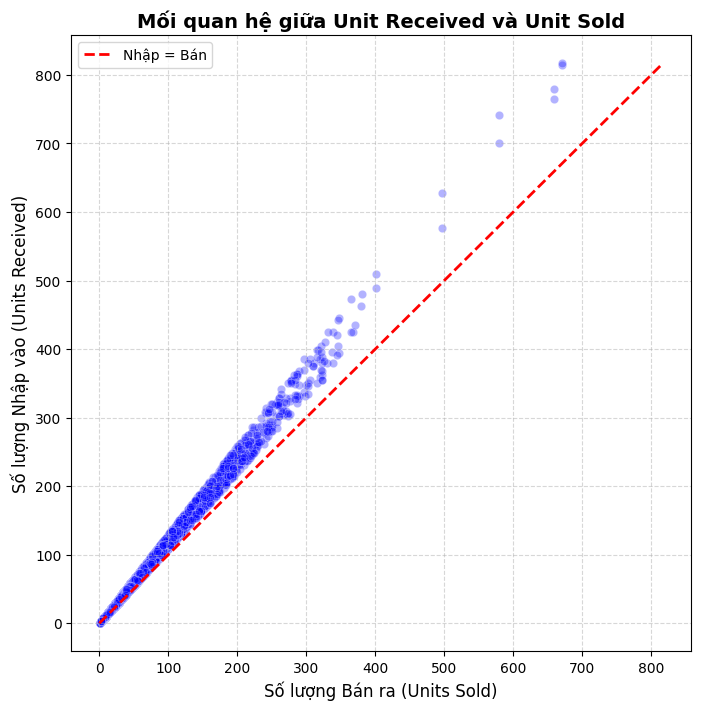

In [66]:
# Giả định df_inventory là bảng chứa dữ liệu của bạn
# 1. TÍNH CHÊNH LỆCH GIỮA NHẬP VÀ BÁN (NET CHANGE)
df_inventory_final['units_difference'] = df_inventory_final['units_received'] - df_inventory_final['units_sold']
print("--- SỰ CHÊNH LỆCH GIỮA NHẬP VÀ BÁN ---")
# Dùng hàm describe() để in ra các mốc phần trăm (percentiles)
diff_stats = df_inventory_final['units_difference'].describe(percentiles=[0.5, 0.75, 0.9, 0.95])
print(diff_stats)


# Vẽ biểu đồ
plt.figure(figsize=(8, 8))
sns.scatterplot(data=df_inventory_final, x='units_sold', y='units_received', alpha=0.3, color='blue')

max_val = max(df_inventory_final['units_sold'].max(), df_inventory_final['units_received'].max())
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', linewidth=2, label='Nhập = Bán')

plt.title('Mối quan hệ giữa Unit Received và Unit Sold', fontsize=14, fontweight='bold')
plt.xlabel('Số lượng Bán ra (Units Sold)', fontsize=12)
plt.ylabel('Số lượng Nhập vào (Units Received)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

--- CORRELATION với stockout_days ---
total_orders        : 0.115
total_quantity      : 0.114
cancelled_orders    : 0.101
cancelled_qty       : 0.097


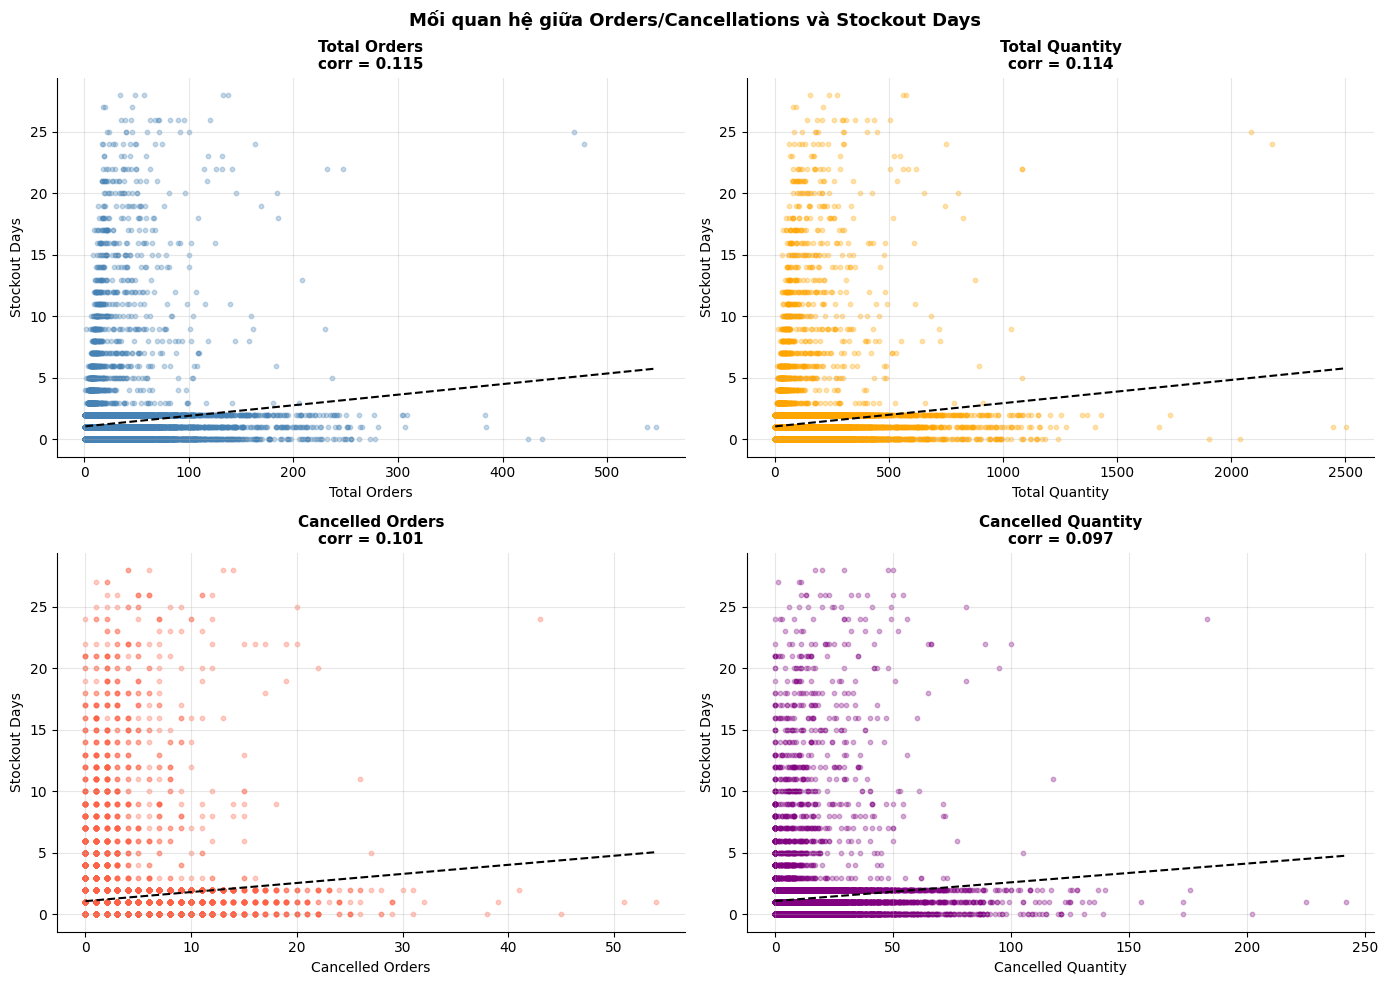

In [ ]:
# order_monthly = df_order_items_final.groupby(['product_id', 'order_month']).agg(
#     total_orders     = ('order_id', 'nunique'),
#     total_quantity   = ('quantity', 'sum'),
#     cancelled_orders = ('order_id', lambda x: x[df_order_items_final.loc[x.index, 'order_status'] == 'cancelled'].nunique()),
#     cancelled_qty    = ('quantity', lambda x: x[df_order_items_final.loc[x.index, 'order_status'] == 'cancelled'].sum())
# ).reset_index().rename(columns={'order_month': 'year_month'})

# # Merge với inventory
# compare_orders = pd.merge(
#     df_inventory_final[['product_id', 'year_month', 'stockout_flag', 'stockout_days', 'stock_on_hand']],
#     order_monthly,
#     on=['product_id', 'year_month'],
#     how='inner'
# )

# # Correlation
# print("--- CORRELATION với stockout_days ---")
# for col in ['total_orders', 'total_quantity', 'cancelled_orders', 'cancelled_qty']:
#     print(f"{col:20s}: {compare_orders[col].corr(compare_orders['stockout_days']):.3f}")

# # Vẽ
# fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# scatter_pairs = [
#     ('total_orders',     'Total Orders',       'steelblue'),
#     ('total_quantity',   'Total Quantity',     'orange'),
#     ('cancelled_orders', 'Cancelled Orders',   'tomato'),
#     ('cancelled_qty',    'Cancelled Quantity', 'purple'),
# ]

# for ax, (col, label, color) in zip(axes.flatten(), scatter_pairs):
#     ax.scatter(compare_orders[col], compare_orders['stockout_days'],
#                alpha=0.3, s=10, color=color)
    
#     z = np.polyfit(compare_orders[col], compare_orders['stockout_days'], 1)
#     p = np.poly1d(z)
#     x_line = np.linspace(compare_orders[col].min(), compare_orders[col].max(), 100)
#     ax.plot(x_line, p(x_line), color='black', linewidth=1.5, linestyle='--')
    
#     corr = compare_orders[col].corr(compare_orders['stockout_days'])
#     ax.set_title(f'{label}\ncorr = {corr:.3f}', fontsize=11, fontweight='bold')
#     ax.set_xlabel(label)
#     ax.set_ylabel('Stockout Days')
#     ax.grid(True, alpha=0.3)
#     ax.spines[['top', 'right']].set_visible(False)

# plt.suptitle('Mối quan hệ giữa Orders/Cancellations và Stockout Days',
#              fontsize=13, fontweight='bold')
# plt.tight_layout()
# plt.show()

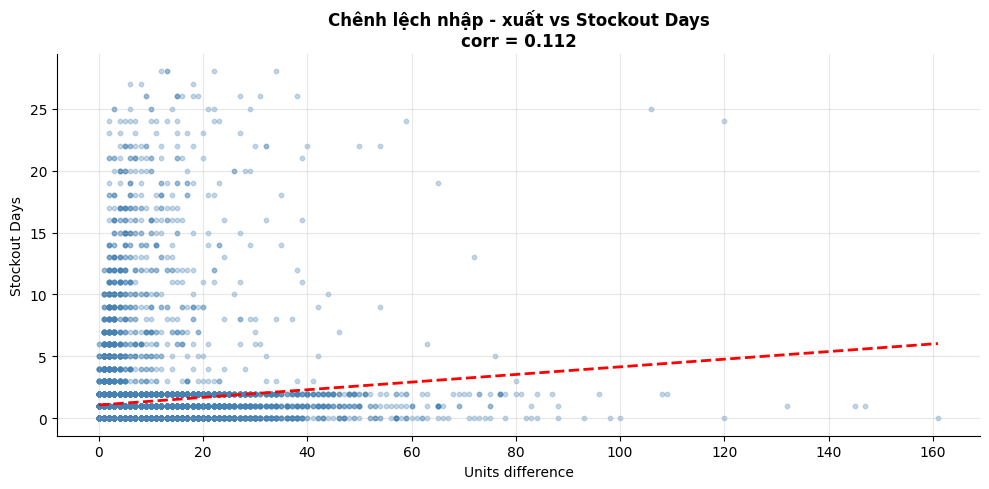

In [ ]:
# corr = df_inventory_final['units_difference'].corr(df_inventory_final['stockout_days'])

# fig, ax = plt.subplots(figsize=(10, 5))

# ax.scatter(df_inventory_final['units_difference'], df_inventory_final['stockout_days'],
#            alpha=0.3, s=10, color='steelblue')

# z = np.polyfit(df_inventory_final['units_difference'], df_inventory_final['stockout_days'], 1)
# p = np.poly1d(z)
# x_line = np.linspace(df_inventory_final['units_difference'].min(), df_inventory_final['units_difference'].max(), 100)
# ax.plot(x_line, p(x_line), color='red', linewidth=2, linestyle='--')

# ax.set_title(f'Chênh lệch nhập - xuất vs Stockout Days\ncorr = {corr:.3f}', fontsize=12, fontweight='bold')
# ax.set_xlabel('Units difference')
# ax.set_ylabel('Stockout Days')
# ax.grid(True, alpha=0.3)
# ax.spines[['top', 'right']].set_visible(False)
# plt.tight_layout()
# plt.show()

## PHÂN TÍCH SỐ LIỆU TỒN KHO

1. Trung bình days_of_supply theo category

In [69]:
# Tính days of supply trung bình theo category-segment
print("Trung bình days_of_supply theo category-segment:")
avg_days_of_supply_cat = df_inventory_final.groupby(['category', 'segment'])['days_of_supply'].mean().reset_index().sort_values(['category', 'days_of_supply'], ascending=False)
display(avg_days_of_supply_cat)


Trung bình days_of_supply theo category-segment:


,category,segment,days_of_supply
6,Streetwear,Everyday,1113.754685
5,Streetwear,Balanced,837.843114
7,Streetwear,Performance,745.608276
8,Streetwear,Standard,353.340134
3,Outdoor,Activewear,1112.712839
4,Outdoor,Premium,822.464802
2,GenZ,Trendy,718.812174
1,Casual,All-weather,494.709672
0,Casual,Activewear,199.386493


    Trong mặt hàng thời trang, theo nhóm research, vòng đời thời trang rất nhanh:
- Fast fashion: 30-45 ngày tồn kho
- Mid-market fashion: 60-90 ngày tồn kho
- Premium/luxury: 90-180 ngày tồn kho
- Basic/Essentials: 73-120 ngày tồn kho \
Tuy vậy, trung bình days_of_supply của từng category và segment lại trên 120 ngày. Ngay cả những phân khúc Trendy, thời trang hợp mốt là fast fashion cũng có thời gian có thể cung cấp hàng lên tới hơn 2 năm. 


2. Tổng lượng vốn chôn chia theo sell-through-rate

In [70]:
df_inventory_final.groupby('overstock_flag')['sell_through_rate'].describe().round(3)

,count,mean,std,min,25%,50%,75%,max
overstock_flag,,,,,,,,
0,14305.0,0.356,0.113,0.25,0.250,0.327,0.415,0.853
1,45942.0,0.089,0.067,0.00,0.031,0.074,0.140,0.250


=> Định nghĩa:
- Dead Mover (STR < 25%): Hàng tồn đọng, khả năng thanh khoản cực thấp.
- Slow Mover (25% ≤ STR < 50%): Hàng luân chuyển chậm.
- Fast Mover (STR > 50%): Hàng lưu thông tốt, hiệu suất bán hàng cao.

--- TABLE: ƯỚC TÍNH VỐN BỊ CHÔN THEO PHÂN TẦNG SKU CUỐI MỖI NĂM (TRIỆU) ---


sku_tier,Dead Movers (< 25%),Fast Movers (> 50%),Slow Movers (25-50%),Total Inventory Capital
year,,,,
2012,102.1,0.9,20.7,123.7
2013,179.7,2.1,15.4,197.2
2014,245.1,1.1,14.7,260.9
2015,303.1,0.6,12.4,316.1
2016,355.6,0.8,17.4,373.8
2017,385.8,0.8,7.2,393.8
2018,402.9,0.1,3.6,406.6
2019,434.0,0.0,4.1,438.2
2020,459.5,0.0,2.3,461.9


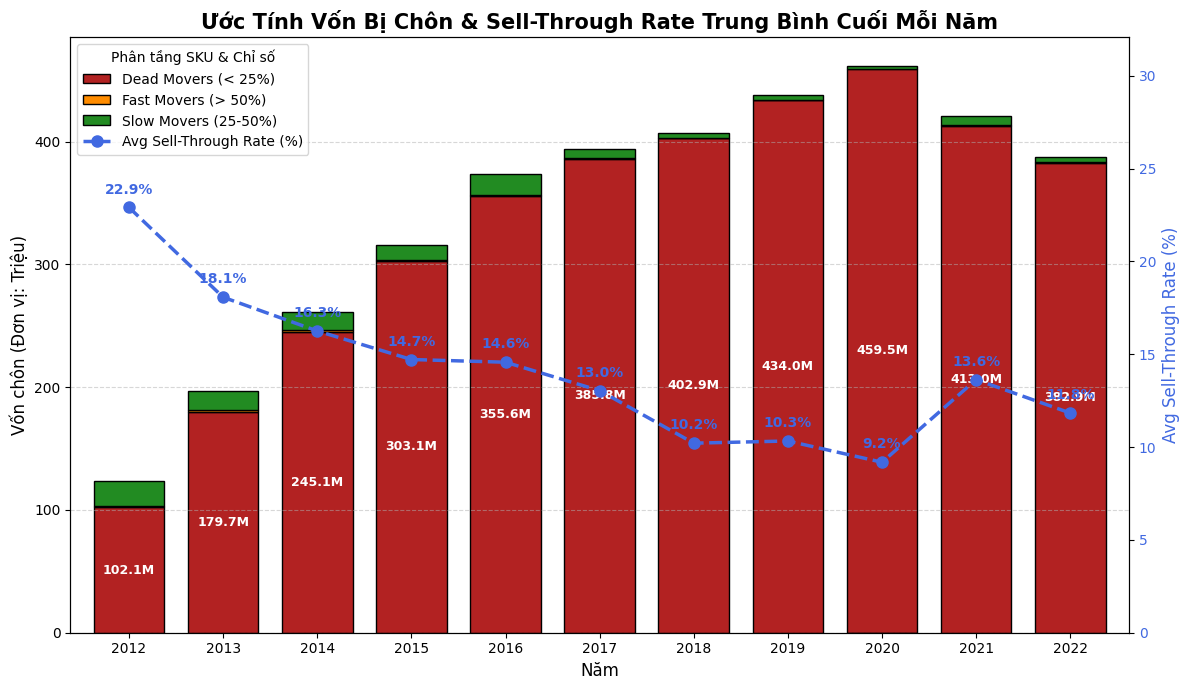

In [71]:
# 1. Phân loại SKU Tiering
def tier_sku(str_rate):
    if str_rate < 0.25:
        return 'Dead Movers (< 25%)'
    elif 0.25 <= str_rate <= 0.50:
        return 'Slow Movers (25-50%)'
    else:
        return 'Fast Movers (> 50%)'

df_inventory_final['sku_tier'] = df_inventory_final['sell_through_rate'].apply(tier_sku)

# 2. Tính Vốn bị chôn
df_inventory_final['locked_capital'] = df_inventory_final['stock_on_hand'] * df_inventory_final['cogs']

# 3. Lọc tháng chốt sổ cuối mỗi năm (Tháng 12)
end_of_year_months = df_inventory_final.groupby('year')['month'].max().reset_index()
df_eoy = pd.merge(df_inventory_final, end_of_year_months, on=['year', 'month'], how='inner')

# 4. Tổng hợp vốn bị chôn theo năm và từng nhóm
yearly_tier_capital = df_eoy.groupby(['year', 'sku_tier'])['locked_capital'].sum().reset_index()
yearly_tier_capital['capital_in_millions'] = yearly_tier_capital['locked_capital'] / 1_000_000

pivot_table = yearly_tier_capital.pivot(
    index='year', columns='sku_tier', values='capital_in_millions'
).fillna(0)
pivot_table['Total Inventory Capital'] = pivot_table.sum(axis=1)

# Tính Sell-Through Rate TRUNG BÌNH của tháng cuối mỗi năm
avg_str_eoy = df_eoy.groupby('year')['sell_through_rate'].mean().reset_index()
avg_str_eoy.columns = ['year', 'avg_str']
avg_str_eoy = avg_str_eoy.set_index('year')

print("--- TABLE: ƯỚC TÍNH VỐN BỊ CHÔN THEO PHÂN TẦNG SKU CUỐI MỖI NĂM (TRIỆU) ---")
display(pivot_table.round(1))

# ==========================================
# 5. Vẽ biểu đồ
# ==========================================
plot_data = pivot_table.drop(columns=['Total Inventory Capital'])
colors = ['firebrick', 'darkorange', 'forestgreen']
dead_mover_col = 'Dead Movers (< 25%)'

fig, ax1 = plt.subplots(figsize=(12, 7))

# --- Stacked Bar (trục Y trái) ---
plot_data.plot(kind='bar', stacked=True, color=colors, ax=ax1, width=0.75, edgecolor='black')

ax1.set_title(
    'Ước Tính Vốn Bị Chôn & Sell-Through Rate Trung Bình Cuối Mỗi Năm',
    fontsize=15, fontweight='bold'
)
ax1.set_xlabel('Năm', fontsize=12)
ax1.set_ylabel('Vốn chôn (Đơn vị: Triệu)', fontsize=12)
ax1.grid(axis='y', linestyle='--', alpha=0.5)
ax1.tick_params(axis='x', rotation=0)

# ✅ Gắn label giá trị lên phần Dead Movers
if dead_mover_col in plot_data.columns:
    for i, (year, row) in enumerate(plot_data.iterrows()):
        dead_val = row[dead_mover_col]
        if dead_val > 0:
            # Dead Movers luôn là segment dưới cùng → y_center = dead_val / 2
            y_center = dead_val / 2
            ax1.text(
                i, y_center,
                f'{dead_val:.1f}M',
                ha='center', va='center',
                fontsize=9, fontweight='bold',
                color='white'
            )

# --- Đường Avg Sell-Through Rate (trục Y phải) ---
ax2 = ax1.twinx()

years = plot_data.index.tolist()
x_positions = range(len(years))
str_values = [avg_str_eoy.loc[y, 'avg_str'] * 100 for y in years]

ax2.plot(
    x_positions, str_values,
    color='royalblue', marker='o', linewidth=2.5,
    markersize=8, linestyle='--', label='Avg Sell-Through Rate (%)'
)

for x, val in zip(x_positions, str_values):
    ax2.annotate(
        f'{val:.1f}%',
        xy=(x, val),
        xytext=(0, 10), textcoords='offset points',
        ha='center', fontsize=10, color='royalblue', fontweight='bold'
    )

ax2.set_ylabel('Avg Sell-Through Rate (%)', fontsize=12, color='royalblue')
ax2.tick_params(axis='y', labelcolor='royalblue')
ax2.set_ylim(0, max(str_values) * 1.4)

# --- Gộp Legend của cả 2 trục ---
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(
    handles1 + handles2, labels1 + labels2,
    title='Phân tầng SKU & Chỉ số',
    fontsize=10, loc='upper left'
)

plt.tight_layout()
plt.show()

3. Biến động units_received, units_sold, stock_on_hand và số lượng SKU qua từng năm

In [72]:
# Giả định df_merged là bảng đã có cột sku_tier (Fast/Slow/Dead Movers) và các cột cơ bản
# 1. Lọc lấy nhóm Dead Movers trong 3 năm quan trọng: 2020, 2021, 2022
df_investigate = df_inventory_final[
                           (df_inventory_final['sku_tier'] == 'Dead Movers (< 25%)')]

# 2. Gom nhóm theo năm để tính tổng các chỉ số "sinh tồn"
investigation_report = df_investigate.groupby('year').agg(
    total_dead_skus=('product_id', 'nunique'),          # Số lượng mã hàng ế (Có giảm bớt không?)
    total_units_received=('units_received', 'sum'),     # Lượng nhập vào (Có bị nghẽn do Covid không?)
    total_units_sold=('units_sold', 'sum'),             # Lượng bán ra (Có xả hàng clearance không?)
    total_stock_on_hand=('stock_on_hand', 'sum')        # Lượng tồn cuối cùng
).reset_index()

# 3. Tính toán tỷ lệ thay đổi (YoY Growth) để thấy rõ sự biến động
# Lấy độ lệch của năm sau trừ năm trước
for col in ['total_dead_skus', 'total_units_received', 'total_units_sold', 'total_stock_on_hand']:
    investigation_report[f'{col}_YoY'] = investigation_report[col].diff()

# Đổi format cho dễ nhìn
print("--- HỒ SƠ ĐIỀU TRA NHÓM DEAD MOVERS (2020 - 2022) ---")
display(investigation_report)

--- HỒ SƠ ĐIỀU TRA NHÓM DEAD MOVERS (2020 - 2022) ---


,year,total_dead_skus,total_units_received,total_units_sold,total_stock_on_hand,total_dead_skus_YoY,total_units_received_YoY,total_units_sold_YoY,total_stock_on_hand_YoY
0,2012,392,28653,24321,126588,NaN,NaN,NaN,NaN
1,2013,517,81879,69713,444217,125.0,53226.0,45392.0,317629.0
2,2014,577,87955,74964,683763,60.0,6076.0,5251.0,239546.0
3,2015,611,108531,92251,891451,34.0,20576.0,17287.0,207688.0
4,2016,639,105289,89448,1047090,28.0,-3242.0,-2803.0,155639.0
5,2017,652,100275,85262,1183385,13.0,-5014.0,-4186.0,136295.0
6,2018,684,93088,79404,1297961,32.0,-7187.0,-5858.0,114576.0
7,2019,666,59766,51446,1334414,-18.0,-33322.0,-27958.0,36453.0
8,2020,688,48735,42241,1374394,22.0,-11031.0,-9205.0,39980.0
9,2021,664,43730,37935,1323394,-24.0,-5005.0,-4306.0,-51000.0


4. Trung bình vốn chôn theo mùa

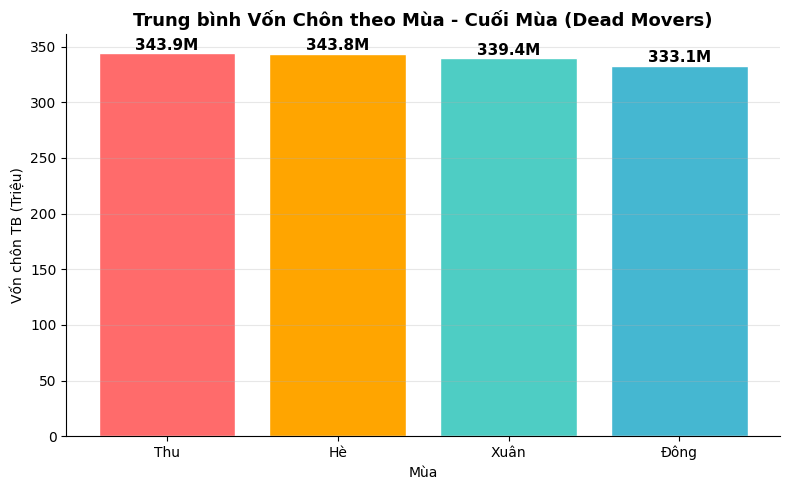

In [73]:
# Lấy tháng cuối của mỗi mùa: tháng 3, 6, 9, 12
end_of_season_months = [3, 6, 9, 12]

df_inventory_final['season'] = df_inventory_final['month'].map({
    1: 'Xuân', 2: 'Xuân', 3: 'Xuân',
    4: 'Hè',   5: 'Hè',   6: 'Hè',
    7: 'Thu',  8: 'Thu',  9: 'Thu',
    10: 'Đông', 11: 'Đông', 12: 'Đông'
})

seasonal_capital = df_inventory_final[
    (df_inventory_final['sku_tier'] == 'Dead Movers (< 25%)') &
    (df_inventory_final['month'].isin(end_of_season_months))  # Chỉ lấy tháng cuối mùa
]\
    .groupby(['year', 'season'])['locked_capital'].sum().reset_index()\
    .groupby('season')['locked_capital'].mean()\
    .reset_index(name='avg_locked_capital')\
    .assign(capital_in_millions=lambda x: x['avg_locked_capital'] / 1_000_000)\
    .sort_values('capital_in_millions', ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(seasonal_capital['season'], seasonal_capital['capital_in_millions'],
              color=['#FF6B6B', '#FFA500', '#4ECDC4', '#45B7D1'], edgecolor='white')

for bar, val in zip(bars, seasonal_capital['capital_in_millions']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val:,.1f}M', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Trung bình Vốn Chôn theo Mùa - Cuối Mùa (Dead Movers)', fontsize=13, fontweight='bold')
ax.set_xlabel('Mùa')
ax.set_ylabel('Vốn chôn TB (Triệu)')
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

5. Top 3 Category x Segment có vốn chôn nhiều nhất qua từng năm

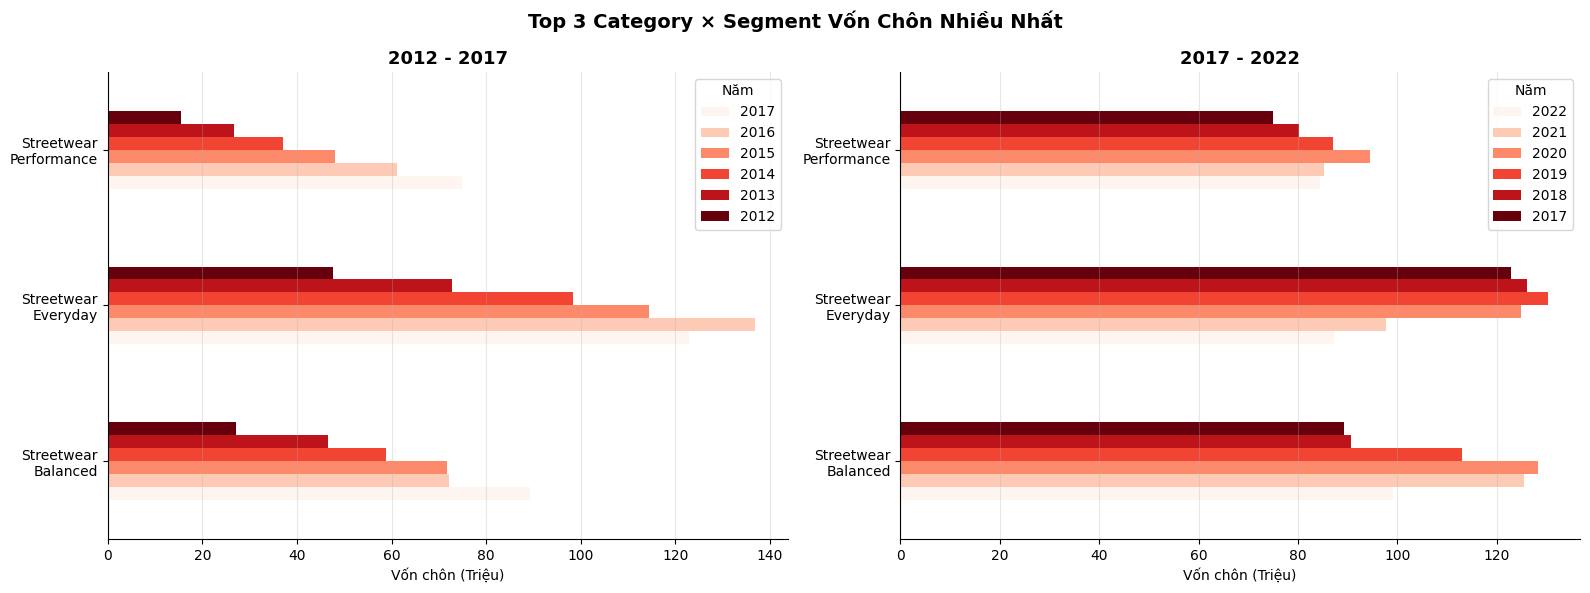

In [74]:
dead_movers_eoy = df_eoy[df_eoy['sku_tier'] == 'Dead Movers (< 25%)']

top_segments = dead_movers_eoy.groupby(['year', 'category', 'segment']).agg(
    total_locked_capital=('locked_capital', 'sum')
).reset_index()\
.assign(
    capital_in_millions=lambda x: x['total_locked_capital'] / 1_000_000,
    combo=lambda x: x['category'] + '\n' + x['segment']
)\
.sort_values(['year', 'total_locked_capital'], ascending=[True, False])\
.groupby('year').head(3)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (start, end) in zip(axes, [(2012, 2017), (2017, 2022)]):
    data = top_segments[(top_segments['year'] >= start) & (top_segments['year'] <= end)]
    
    pivot = data.pivot_table(index='combo', columns='year', values='capital_in_millions', aggfunc='sum').fillna(0)
    pivot = pivot[sorted(pivot.columns, reverse=True)]  # Sắp xếp năm từ mới -> cũ
    pivot.plot(kind='barh', ax=ax, colormap='Reds')
    
    ax.set_title(f'{start} - {end}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Vốn chôn (Triệu)')
    ax.set_ylabel('')
    ax.grid(axis='x', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(title='Năm', bbox_to_anchor=(1, 1))

fig.suptitle('Top 3 Category × Segment Vốn Chôn Nhiều Nhất', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
plt.show()

6. Top 10 sản phẩm tồn kho cao nhưng units_sold vẫn nhiều

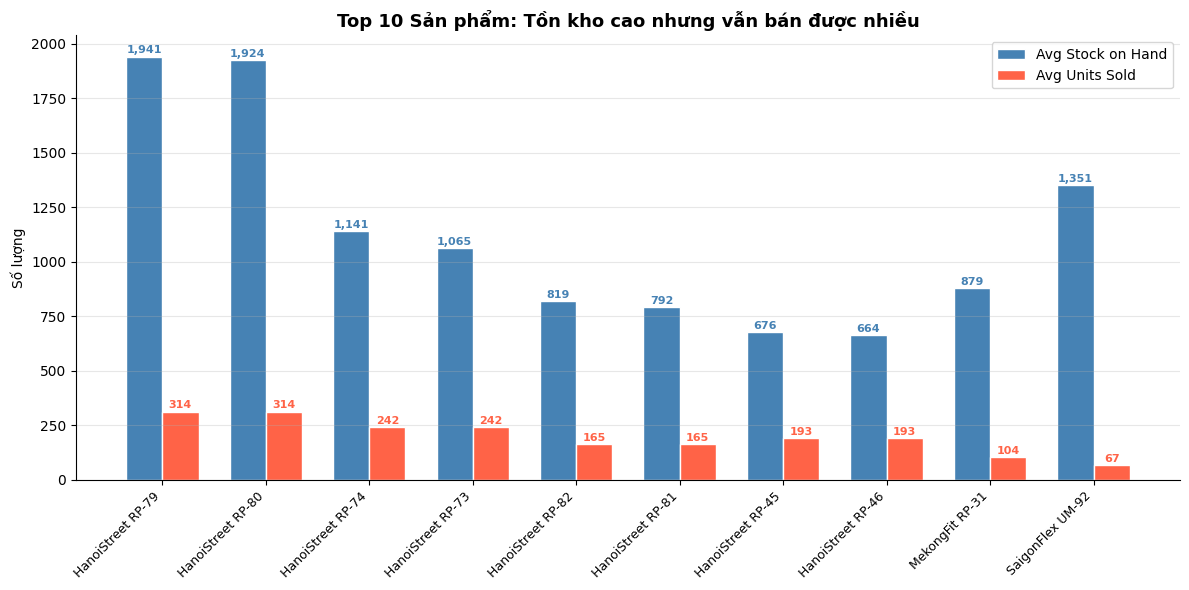

In [75]:
top10 = df_inventory_final[df_inventory_final['month'] == 12]\
    .groupby(['product_id', 'product_name']).agg(
        avg_eoy_stock = ('stock_on_hand', 'mean'),
        avg_eoy_sold  = ('units_sold', 'mean')
    ).reset_index()\
    .assign(combined_score = lambda x: x['avg_eoy_stock'] * x['avg_eoy_sold'])\
    .sort_values('combined_score', ascending=False)\
    .head(10)

fig, ax = plt.subplots(figsize=(12, 6))

x = range(len(top10))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], top10['avg_eoy_stock'], width, 
               label='Avg Stock on Hand', color='steelblue', edgecolor='white')
bars2 = ax.bar([i + width/2 for i in x], top10['avg_eoy_sold'], width, 
               label='Avg Units Sold', color='tomato', edgecolor='white')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{bar.get_height():,.0f}', ha='center', va='bottom', fontsize=8, color='steelblue', fontweight='bold')

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{bar.get_height():,.0f}', ha='center', va='bottom', fontsize=8, color='tomato', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(top10['product_name'], rotation=45, ha='right', fontsize=9)
ax.set_title('Top 10 Sản phẩm: Tồn kho cao nhưng vẫn bán được nhiều', fontsize=13, fontweight='bold')
ax.set_ylabel('Số lượng')
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()
plt.show()

7. Top 10 sản phẩm units_sold cao và tồn kho thấp

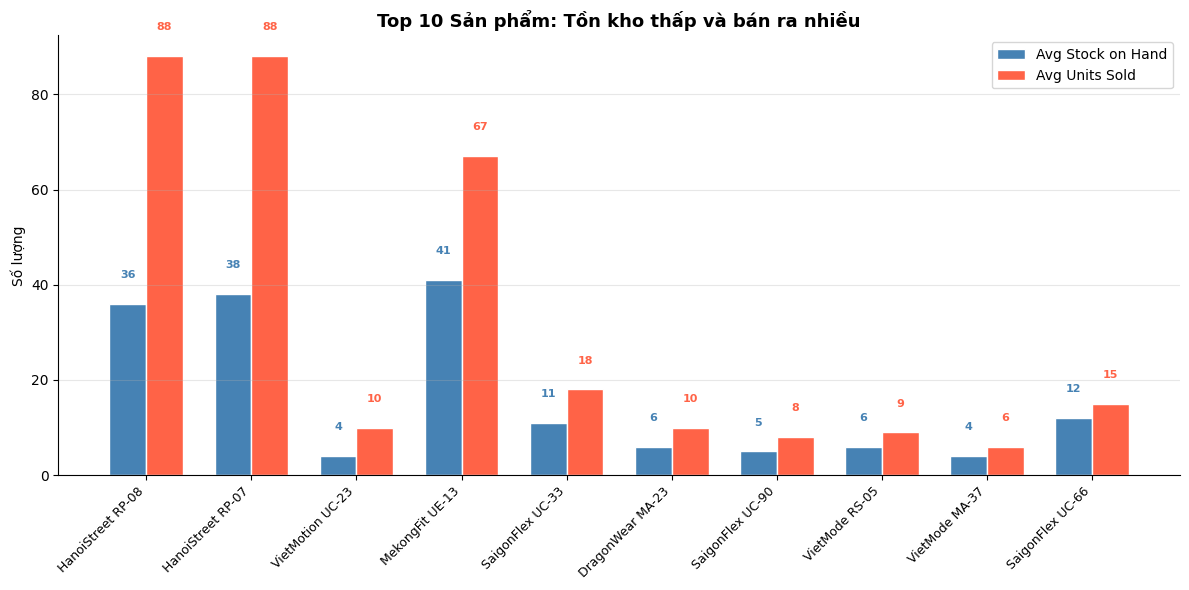

In [76]:
top10_fast = df_inventory_final[df_inventory_final['month'] == 12]\
    .groupby(['product_id', 'product_name']).agg(
        avg_eoy_stock = ('stock_on_hand', 'mean'),
        avg_eoy_sold  = ('units_sold', 'mean')
    ).reset_index()\
    .assign(combined_score = lambda x: x['avg_eoy_sold'] / (x['avg_eoy_stock'] + 1))\
    .sort_values('combined_score', ascending=False)\
    .head(10)

fig, ax = plt.subplots(figsize=(12, 6))

x = range(len(top10_fast))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], top10_fast['avg_eoy_stock'], width, 
               label='Avg Stock on Hand', color='steelblue', edgecolor='white')
bars2 = ax.bar([i + width/2 for i in x], top10_fast['avg_eoy_sold'], width, 
               label='Avg Units Sold', color='tomato', edgecolor='white')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{bar.get_height():,.0f}', ha='center', va='bottom', fontsize=8, color='steelblue', fontweight='bold')

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{bar.get_height():,.0f}', ha='center', va='bottom', fontsize=8, color='tomato', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(top10_fast['product_name'], rotation=45, ha='right', fontsize=9)
ax.set_title('Top 10 Sản phẩm: Tồn kho thấp và bán ra nhiều', fontsize=13, fontweight='bold')
ax.set_ylabel('Số lượng')
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()
plt.show()